In [1]:
import h5py
import quimb as qu
import quimb.tensor as qtn
import numpy as np

In [2]:
from scipy.linalg import sqrtm

### Read data

In [3]:
with h5py.File("M1_a0.h5", "r") as f:
    keys = sorted(f.keys(), key=lambda x: int(x.split("_")[1]))
    print(keys)
    M1 = [np.transpose(f[key][:], (3,2,1,0)) for key in keys]

with h5py.File("M2_a0.h5", "r") as g:
    keys = sorted(g.keys(), key=lambda x: int(x.split("_")[1]))
    print(keys)
    M2 = [np.transpose(g[key][:], (3,2,1,0)) for key in keys]

['arr_1', 'arr_2', 'arr_3', 'arr_4', 'arr_5', 'arr_6', 'arr_7', 'arr_8', 'arr_9', 'arr_10']
['arr_1', 'arr_2', 'arr_3', 'arr_4', 'arr_5', 'arr_6', 'arr_7', 'arr_8', 'arr_9', 'arr_10']


In [4]:
for i in range(len(M1)):
    print(M1[i].shape, M2[i].shape)

(1, 2, 2, 2) (1, 2, 2, 2)
(2, 2, 2, 4) (2, 2, 2, 4)
(4, 2, 2, 8) (4, 2, 2, 8)
(8, 2, 2, 14) (8, 2, 2, 14)
(14, 2, 2, 18) (14, 2, 2, 18)
(18, 2, 2, 14) (18, 2, 2, 14)
(14, 2, 2, 8) (14, 2, 2, 8)
(8, 2, 2, 4) (8, 2, 2, 4)
(4, 2, 2, 2) (4, 2, 2, 2)
(2, 2, 2, 1) (2, 2, 2, 1)


In [5]:
def array_to_lpdo(M, tags):
    # convert input list of arrays to LPDO

    L = len(M)

    inds = ('k0','b0','l0')
    first_tensor = M[0][0,:,:,:]
    last_tensor = M[-1][:,:,:,0]
    lpdo_1 = qtn.Tensor(data=first_tensor, inds=inds, tags=tags + ['Site 1'])

    for i in range(1, L):
        if i == L-1:
            inds = (f'l{i-1}', f'k{i}', f'b{i}')
            current_tensor = qtn.Tensor(data=last_tensor, inds=inds, tags=tags + [f'Site {L}'])
        else:
            inds = (f'l{i-1}', f'k{i}', f'b{i}', f'l{i}')
            current_tensor = qtn.Tensor(data=M[i], inds=inds, tags=tags + [f'Site {i+1}'])

        lpdo_1 = lpdo_1 & current_tensor

    return lpdo_1

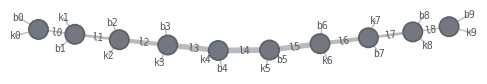

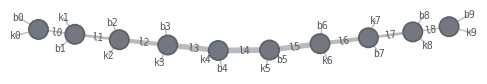

In [87]:
lpdo_1 = array_to_lpdo(M1, ['M1'])
lpdo_2 = array_to_lpdo(M2, ['M2'])
lpdo_1.draw(show_inds='all',show_tags=False)
lpdo_2.draw(show_inds='all',show_tags=False)

In [7]:
all_tensors = lpdo_1.tensors

# Iterate through tensors and print their tags
for i, tensor in enumerate(all_tensors):
    print(f"Tensor {i}: Tags = {tensor.tags}")

Tensor 0: Tags = oset(['M1', 'Site 1'])
Tensor 1: Tags = oset(['M1', 'Site 2'])
Tensor 2: Tags = oset(['M1', 'Site 3'])
Tensor 3: Tags = oset(['M1', 'Site 4'])
Tensor 4: Tags = oset(['M1', 'Site 5'])
Tensor 5: Tags = oset(['M1', 'Site 6'])
Tensor 6: Tags = oset(['M1', 'Site 7'])
Tensor 7: Tags = oset(['M1', 'Site 8'])
Tensor 8: Tags = oset(['M1', 'Site 9'])
Tensor 9: Tags = oset(['M1', 'Site 10'])


In [89]:
def complex_conjugate_mpdo(lpdo):
    # Create a deep copy of the MPDO
    lpdo_copy = lpdo.copy()
    
    # Iterate through all tensors and apply complex conjugate to their data
    for tensor in lpdo_copy.tensors:
        # Complex conjugate the tensor's data
        conjugated_data = np.conj(tensor.data)
        # Update the tensor with the conjugated data, preserving indices and tags
        tensor.modify(data=conjugated_data)
        current_inds = tensor.inds
        new_inds = tuple(ind + '*' if ind[0] == 'l' else ind for ind in current_inds)
        tensor.modify(inds=new_inds)
    return lpdo_copy

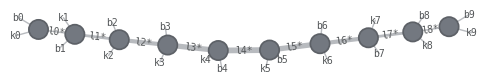

In [9]:
lpdo_2_conj = complex_conjugate_mpdo(lpdo_2)   
lpdo_2_conj.draw(show_inds='all',show_tags=False)

In [10]:
lpdo_1.tensors

(Tensor(shape=(2, 2, 2), inds=('k0', 'b0', 'l0'), tags=oset(['M1', 'Site 1'])),
 Tensor(shape=(2, 2, 2, 4), inds=('l0', 'k1', 'b1', 'l1'), tags=oset(['M1', 'Site 2'])),
 Tensor(shape=(4, 2, 2, 8), inds=('l1', 'k2', 'b2', 'l2'), tags=oset(['M1', 'Site 3'])),
 Tensor(shape=(8, 2, 2, 14), inds=('l2', 'k3', 'b3', 'l3'), tags=oset(['M1', 'Site 4'])),
 Tensor(shape=(14, 2, 2, 18), inds=('l3', 'k4', 'b4', 'l4'), tags=oset(['M1', 'Site 5'])),
 Tensor(shape=(18, 2, 2, 14), inds=('l4', 'k5', 'b5', 'l5'), tags=oset(['M1', 'Site 6'])),
 Tensor(shape=(14, 2, 2, 8), inds=('l5', 'k6', 'b6', 'l6'), tags=oset(['M1', 'Site 7'])),
 Tensor(shape=(8, 2, 2, 4), inds=('l6', 'k7', 'b7', 'l7'), tags=oset(['M1', 'Site 8'])),
 Tensor(shape=(4, 2, 2, 2), inds=('l7', 'k8', 'b8', 'l8'), tags=oset(['M1', 'Site 9'])),
 Tensor(shape=(2, 2, 2), inds=('l8', 'k9', 'b9'), tags=oset(['M1', 'Site 10'])))

In [90]:
def compute_mpdo_trace(lpdo):
    # Create a copy of the MPDO to avoid modifying the original
    lpdo_copy = lpdo.copy()
    lpdo_conj = complex_conjugate_mpdo(lpdo_copy)
    
    # Contract the entire network to compute the trace
    trace = (lpdo_copy & lpdo_conj).contract(all, output_inds=())
    return trace

trace_value = compute_mpdo_trace(lpdo_1)
print("Trace of the MPDO:", trace_value)

Trace of the MPDO: 1.000000000000002


In [12]:
def lpdo_to_dense_matrix(lpdo):
    # Get the number of sites
    L = len(lpdo.tensors)
    
    # Identify all physical indices
    ket_indices = [f'k{i}' for i in range(L)]
    bra_indices = [f'b{i}' for i in range(L)]
    output_inds = ket_indices + bra_indices  # Order: k0, k1, ..., k{L-1}, l0, l1, ..., l{L-1}
    
    # Contract the LPDO, keeping physical indices open
    dense_tensor = lpdo.contract(all, output_inds=output_inds)
    
    # Get the physical dimension (assumed same for all sites)
    d = lpdo.tensors[0].shape[lpdo.tensors[0].inds.index('k0')]  # e.g., 2 for qubits
    
    # Reshape the tensor into a (d^L, d^L) matrix
    dense_matrix = dense_tensor.data.reshape(d**L, d**L)
    
    return np.matrix(dense_matrix)

In [13]:
psi1 = lpdo_to_dense_matrix(lpdo_1)
rho1 = psi1 @ psi1.H

psi2 = lpdo_to_dense_matrix(lpdo_2)
rho2 = psi2 @ psi2.H

In [14]:
def compute_fidelity_dense(rho1, rho2):
    rho1 = (rho1 + rho1.H)/2
    rho2 = (rho2 + rho2.H)/2
    sqrt_rho1 = sqrtm(rho1)
    sqrt_rho2 = sqrtm(rho2)
    product = sqrt_rho1 @ sqrt_rho2
    
    # Compute singular values of the product
    singular_values = np.linalg.svd(product, compute_uv=False)
    
    # Sum the singular values to get the fidelity
    fidelity = np.sum(np.abs(singular_values))  # Use abs to handle small negative values
    
    # Ensure real output (fidelity should be real for Hermitian inputs)
    fidelity = np.real(fidelity)
    return fidelity
    

In [15]:
compute_fidelity_dense(rho1, rho1)

np.float64(1.0000000000000098)

In [16]:
compute_fidelity_dense(rho2, rho2)

np.float64(1.0000000000000067)

In [17]:
compute_fidelity_dense(rho1, rho2)

np.float64(0.48240004625002864)

In [18]:
np.trace(rho1 @ rho2)

np.float64(0.0038194352073019824)

# Torch optimizer

In [91]:
import torch
import torch.nn as nn

In [98]:
def build_staircase_unitary(L, rand=True, seed=None):
    """
    Build a staircase unitary circuit that acts on 'b' indices of an LPDO.
    
    Staircase structure means the output of gate i feeds into the input of gate i+1.
    Specifically: the 4th index (right output) of gate i contracts with 
    the 1st index (left input) of gate i+1.
    
    Args:
        L: number of sites (number of gates = L-1)
        rand: if True, initialize with random unitaries, else identity
        seed: random seed for reproducibility
    
    Returns:
        TensorNetwork representing the unitary circuit
    """
    if seed is not None:
        np.random.seed(seed)
    
    gate_tensors = []
    
    # Build L-1 gates for L sites
    for i in range(L - 1):
        if rand:
            U = qu.rand_uni(4, dtype=complex)
        else:
            U = qu.identity(4, dtype=complex)
        
        # Reshape 4x4 matrix to (2,2,2,2) tensor
        # Convention: U[left_in, right_in, left_out, right_out]
        U_reshaped = U.reshape(2, 2, 2, 2)
        
        # For staircase: gate i acts on sites (i, i+1)
        # Left input (site i):
        if i == 0:
            left_in = f'b_in{i}'
        else:
            left_in = f'b_inter{i}'  # Comes from previous gate's right output
        
        # Right input (site i+1):
        right_in = f'b_in{i+1}'
        
        # Left output (site i):
        left_out = f'b_out{i}'
        
        # Right output (site i+1):
        if i == L - 2:
            right_out = f'b_out{i+1}'  # Last gate outputs to lpdo_2
        else:
            right_out = f'b_inter{i+1}'  # Feeds into next gate's left input
        
        inds = (left_in, right_in, left_out, right_out)
        
        gate_tensor = qtn.Tensor(data=U_reshaped, inds=inds,
                                tags=['U', f'G{i}', f'Gate_{i}_{i+1}'])
        gate_tensors.append(gate_tensor)
    
    # Combine gates - b_inter indices will contract automatically
    # Gate i's right_out (b_inter{i+1}) = Gate i+1's left_in (b_inter{i+1})
    U_circuit = gate_tensors[0]
    for gate in gate_tensors[1:]:
        U_circuit = U_circuit & gate
    
    return U_circuit


def compute_overlap(lpdo_1, lpdo_2_conj, U_circuit, L):
    """
    Compute <lpdo_2| U |lpdo_1> where U is a staircase circuit.
    
    The unitary circuit U is composed of gates U_i acting on adjacent sites.
    We need to properly connect: lpdo_1 -> U -> lpdo_2
    
    Args:
        lpdo_1: first LPDO (TensorNetwork)
        lpdo_2_conj: second LPDO conjuagated (TensorNetwork)  
        U_circuit: unitary circuit (TensorNetwork)
        L: number of sites
    
    Returns:
        overlap value (scalar)
    """
    # Make copies to avoid modifying originals
    lpdo_1_copy = lpdo_1.copy()
    U_copy = U_circuit.copy()
    
    # Connect lpdo_1 'b' indices to U input indices
    for i in range(L):
        lpdo_1_copy = lpdo_1_copy.reindex({f'b{i}': f'b_in{i}'})
    
    lpdo_2_conj_copy = lpdo_2_conj.copy()
    for i in range(L):
        lpdo_2_conj_copy = lpdo_2_conj_copy.reindex({f'b{i}': f'b_out{i}'})
    
    # Now contract everything: <lpdo_2| U |lpdo_1>
    # All b_in indices connect lpdo_1 to U
    # All b_out indices connect U to lpdo_2_conj
    # Gates share overlapping b_in and b_out indices - they will contract with each other!
    full_tn = lpdo_2_conj_copy & U_copy & lpdo_1_copy
    result = full_tn.contract(optimize='auto')
    #full_tn.draw(show_inds='all',show_tags=False)
    return result

In [99]:
U = build_staircase_unitary(10,rand=True)
lpdo_2_conj = complex_conjugate_mpdo(lpdo_2)
overlap_initial = compute_overlap(lpdo_1,lpdo_2_conj,U,10)
overlap_initial

np.complex128(-0.0004460770758377779-0.0007006055637064836j)

In [ ]:
class LPDOUnitaryModel(nn.Module):
    """
    PyTorch model for optimizing staircase unitary between two LPDOs.
    Bypasses quimb's PArray system using pack/unpack.
    Uses projection to unitary manifold via QR decomposition during forward pass.
    """
    
    def __init__(self, lpdo_1, lpdo_2, L, init_random=True, seed=None):
        """
        Args:
            lpdo_1: first LPDO (target state input)
            lpdo_2: second LPDO (target state output)
            L: number of sites
            init_random: initialize gates randomly (True) or as identity (False)
            seed: random seed
        """
        super().__init__()
        
        self.L = L
        self.lpdo_1 = lpdo_1
        self.lpdo_2 = lpdo_2
        
        # Build initial unitary circuit
        U_circuit = build_staircase_unitary(L, rand=init_random, seed=seed)
        
        # Convert to PyTorch tensors (safe conversion)
        def to_torch(x):
            if isinstance(x, torch.Tensor):
                return x.detach().clone().requires_grad_(False)
            else:
                return torch.tensor(x, dtype=torch.complex128)
        
        U_circuit.apply_to_arrays(to_torch)
        
        # Extract parameters using pack/unpack
        params, self.skeleton = qtn.pack(U_circuit)
        
        # Register as PyTorch parameters
        self.torch_params = nn.ParameterDict({
            str(i): nn.Parameter(initial)
            for i, initial in params.items()
        })
        
        # Loss function
        self._loss_fn = lambda U: compute_overlap(self.lpdo_1, self.lpdo_2, U, self.L)
    
    def forward(self):
        """
        Compute negative overlap: -|<lpdo_2| U |lpdo_1>|^2
        (negative for minimization)
        
        Projects to unitary manifold during forward pass using QR decomposition.
        """
        # Convert back to original int key format
        params = {int(i): p for i, p in self.torch_params.items()}
        
        # Reconstruct the TN with the new parameters
        U_circuit = qtn.unpack(params, self.skeleton)
        
        # Project to unitary manifold using differentiable QR projection
        U_circuit = self._project_to_unitary_qr(U_circuit)
        
        # Compute overlap
        overlap = self._loss_fn(U_circuit)
        
        # Return negative squared magnitude for minimization
        return -torch.abs(overlap) ** 2
    
    def _project_to_unitary_qr(self, U_circuit):
        """
        Project each gate tensor to unitary manifold using QR-based SVD projection.
        This maintains unitarity while being differentiable.
        """
        for tensor in U_circuit.tensors:
            if 'U' in tensor.tags:
                # Get the gate data (shape: 2,2,2,2)
                gate_data = tensor.data
                original_shape = gate_data.shape
                
                # Reshape to 4x4 matrix
                gate_matrix = gate_data.reshape(4, 4)
                
                # Project to nearest unitary using SVD: U_proj = U @ V^H
                U_mat, S, Vh = torch.linalg.svd(gate_matrix, full_matrices=False)
                unitary_matrix = U_mat @ Vh
                
                # Reshape back to original shape
                unitary_gate = unitary_matrix.reshape(original_shape)
                
                # Update tensor with projected unitary
                tensor.modify(data=unitary_gate)
        
        return U_circuit
    
    def get_unitary_circuit(self):
        """Return the current unitary circuit (projected to unitary manifold)"""
        params = {int(i): p for i, p in self.torch_params.items()}
        U_circuit = qtn.unpack(params, self.skeleton)
        return self._project_to_unitary_qr(U_circuit)
    
    def get_overlap(self):
        """Return current overlap value (not negated)"""
        U_circuit = self.get_unitary_circuit()
        overlap = self._loss_fn(U_circuit)
        return torch.abs(overlap) ** 2


def train_lpdo_unitary(model, optimizer, num_steps=1000, early_stop_tol=1e-10, 
                       scheduler=None, verbose=True):
    """
    Train the LPDO unitary model.
    
    Args:
        model: LPDOUnitaryModel instance
        optimizer: PyTorch optimizer
        num_steps: number of training steps
        early_stop_tol: tolerance for early stopping
        scheduler: optional learning rate scheduler
        verbose: print progress
    
    Returns:
        losses: list of loss values
    """
    import tqdm
    
    losses = []
    overlaps = []
    previous_loss = torch.tensor(float('inf'))
    
    pbar = tqdm.tqdm(range(num_steps)) if verbose else range(num_steps)
    
    for step in pbar:
        optimizer.zero_grad()
        loss = model.forward()
        
        losses.append(loss.detach().item())
        overlap = model.get_overlap().detach().item()
        overlaps.append(overlap)
        
        loss.backward()
        optimizer.step()
        
        if scheduler is not None:
            scheduler.step()
        
        if verbose:
            pbar.set_description(f"Loss={loss.item():.6e}, Overlap={overlap:.6f}")
        
        # Early stopping
        if step > 100 and torch.abs(previous_loss - loss) < early_stop_tol:
            if verbose:
                print(f"Early stopping at step {step}")
            break
        
        previous_loss = loss.clone()
    
    return losses, overlaps


# Example usage
# Main optimization function
def optimize_lpdo_unitary(lpdo_1, lpdo_2, L, init_random=True, seed=None, 
                         lr=0.01, num_steps=500, scheduler_step=200, 
                         scheduler_gamma=0.5, early_stop_tol=1e-10, verbose=True):
    """
    Optimize staircase unitary to maximize overlap <lpdo_2| U |lpdo_1>
    
    Args:
        lpdo_1: first LPDO (qtn.TensorNetwork)
        lpdo_2: second LPDO (qtn.TensorNetwork)
        L: number of sites
        init_random: initialize gates randomly (True) or as identity (False)
        seed: random seed for reproducibility
        lr: learning rate
        num_steps: number of optimization steps
        scheduler_step: step size for learning rate scheduler
        scheduler_gamma: multiplicative factor for learning rate decay
        early_stop_tol: tolerance for early stopping
        verbose: print progress
    
    Returns:
        model: trained LPDOUnitaryModel
        losses: list of loss values
        overlaps: list of overlap values
    """
    # Convert to PyTorch tensors (safe conversion)
    def to_torch(x):
        if isinstance(x, torch.Tensor):
            return x.detach().clone().requires_grad_(False)
        else:
            return torch.tensor(x, dtype=torch.complex128)
    
    lpdo_1.apply_to_arrays(to_torch)
    lpdo_2.apply_to_arrays(to_torch)
    
    # Create model
    model = LPDOUnitaryModel(lpdo_1, lpdo_2, L, init_random=init_random, seed=seed)
    
    # Setup optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=scheduler_step, 
                                               gamma=scheduler_gamma)
    
    # Train
    losses, overlaps = train_lpdo_unitary(model, optimizer, num_steps=num_steps,
                                         early_stop_tol=early_stop_tol,
                                         scheduler=scheduler, verbose=verbose)
    
    if verbose:
        print(f"\nInitial overlap: {overlaps[0]:.6f}")
        print(f"Final overlap: {overlaps[-1]:.6f}")
    
    return model, losses, overlaps


In [69]:
optimize_lpdo_unitary(lpdo_1, lpdo_2, 10)

  0%|          | 0/500 [00:00<?, ?it/s]C:\Users\yijia\AppData\Local\Temp\ipykernel_16072\537474343.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  conjugated_data = np.conj(tensor.data)
Loss=-6.468442e-07, Overlap=0.000001:   0%|          | 1/500 [00:00<00:17, 28.65it/s]


_LinAlgError: linalg.svd: The algorithm failed to converge because the input matrix contained non-finite values.

### Circuit

In [20]:
def staircase(circ, reverse=False, gate_round=None):
    regs = range(0, circ.N - 1)
    if reverse:
        regs = reversed(regs)
    
    for i in regs:
        u = qtn.array_ops.PArray(
            params=np.random.randn(4, 4),  # Use numpy for random init
            fn=qtn.decomp.isometrize,      # Constraint for isometric gate
        )
        circ.apply_gate(
            u, i, i+1, gate_round=gate_round
        )

def ansatz_circuit(n, depth, **kwargs):
    """Construct a circuit of single qubit and entangling layers."""
    circ = qtn.Circuit(n, **kwargs)
    
    for r in range(depth):
        staircase(
            circ, gate_round=r, reverse=r % 2 == 0
        )
    
    return circ

# Example usage
n = 10
depth = 2
circ = ansatz_circuit(n, depth)
print(circ)

ImportError: autoray couldn't find function 'reshape' for backend 'quimb'.

In [13]:
n = 10
depth = 2

circ = ansatz_circuit(n, depth)
circ

ValueError: You cannot specify ``parametrize`` for raw gate, supply a ``PArray`` instead.

In [18]:
V = circ.uni

c:\Users\yliu\anaconda3\Lib\site-packages\quimb\tensor\circuit.py:2587: FutureWarning: In future the tensor network returned by ``circ.uni`` will not be transposed as it is currently, to match the expectation from ``U = circ.uni.to_dense()`` behaving like ``U @ psi``. You can retain this behaviour with ``circ.get_uni(transposed=True)``.
  warnings.warn(


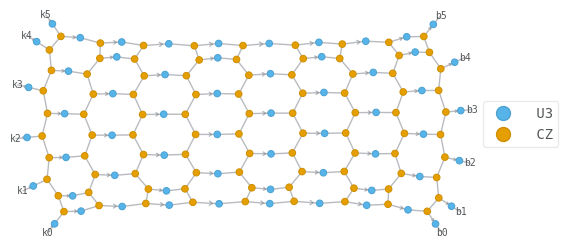

In [19]:
V.draw(color=['U3', gate2], show_inds=True)

In [22]:
V

TensorNetworkGenOperator(tensors=150, indices=201)

In [ ]:
def loss(V, U):
    return 1 - abs((V.H & U).contract(all, optimize='auto-hq')) / 2**n

# check our current unitary 'infidelity':
loss(V, U)